# Seeing Earth at the Edge
## Part 2 — The adaptive vision transformer 

**Task:** 45-class classification of overhead remote sensing images from NWPU-RESISC45.  
**Scope of this notebook:** train a **shared early-exit vision transformer**, calibrate a confidence-aware and budget-aware stopping policy, and evaluate the resulting accuracy–computation tradeoff.

Part 1 established a static DeiT-Tiny baseline. This notebook (1) starts by using its saved **`best.pt`** weights, (2) uses that model as a new baseline that will act as the frozen 'teacher' model for knowledge distillation, and (3) trains a separate copy with prediction exits after blocks **4, 8, and 12**. The original baseline is preserved.

**Research question**: Can input-dependent early exiting reduce average inference computation while preserving classification accuracy, and can the same model respond to changing per-image compute allowances?

Knowledge distillation supports the cheaper exits (**compression**); and selecting an exit at runtime provides **adaptivity**. All exits share one transformer trunk. The final evaluation compares the frozen static baseline, fixed-depth configurations of the adaptive model, and confidence-based policies on the same held-out images [C1, R1–R3].

### Experimental protocol:

- **`train` (18,900 images):** adaptive model training.
- **`val_select` (3,150):** adaptive checkpoint selection, as in Part 1.
- **`val_policy` (3,150):** separately partitioned for confidence calibration and policy selection.
- **`test` (6,300):** evaluated only after the model, calibration method, stopping thresholds and resource schedule have been fixed.

The resource schedule is simulated; RESISC45 is not a chronological sensor stream. Accuracy–FLOPs results are computed from actual image predictions and profiled execution paths, rather than assumed savings. CPU latency measurements use genuinely conditional execution, not a replay of cached outputs.

**Execution:** Run from the repository root in the environment defined by `requirements.txt`. A one-epoch `smoke` run checks the implementation without touching test images; `full` performs the complete experiment. Training artifacts remain under `runs/`, outside version control.

## 2A — Static reference, environment and dataset

### Loading the results of Part 1

The existing baseline run already contains the checkpoint, class mapping, preprocessing settings, split manifest, and FLOPs reference. We reuse these files directly, without rerunning the static notebook or downloading the dataset again.

The checkpoint hash is checked against `baseline_summary.json`, which protects the reference from silent replacement. An optional approved copy under `runs/references/` is not required: the `best.pt` checkpoint shown in Part 1's run directory is sufficient, provided its hash matches the recorded summary.

In [1]:
# importing the experiment dependencies
import copy
import hashlib
import json
import math
import platform
import random
import sys
import time
from contextlib import nullcontext
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from fvcore.nn import FlopCountAnalysis
from fvcore.nn.jit_handles import get_shape
#from tqdm.auto import tqdm
from tqdm import tqdm

if sys.version_info[:2] not in {(3, 12), (3, 13)}:
    raise RuntimeError("This project environment uses Python 3.12 or 3.13.")

/Users/waronig/Developer/adaptive-inference-edge/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### One settings cell

The repository is the current working directory and contains `requirements.txt`. Settings in this cell define the adaptive experiment; changing the training configuration after a run has started requires a new run name. Device paths and local hardware are not part of the experiment identity.

The adaptive checkpoint is selected using a weighted average of accuracy at exits 4, 8 and 12 (weights 0.2, 0.3 and 0.5). This is fixed **before training**, favouring full-depth quality while requiring useful earlier predictions. Distillation and learning-rate settings are initial design choices, not the outcome of an architecture search.

In [ ]:
# configuring the experiment
ROOT = Path.cwd().resolve()
DATA_DIR = ROOT / "data" / "NWPU-RESISC45"
BASELINE_DIR = ROOT / "runs" / "baseline_deit_tiny_seed42"
RUN_NAME = "adaptive_deit_tiny_seed42"
RUN_MODE = "full"                    # changing to "full" after the pipeline check
DEVICE = "auto"                       # using CUDA, Apple MPS, or CPU

BATCH_SIZE = 32
ADAPTIVE_EPOCHS = 15
BACKBONE_LR = 2e-5
EXIT_HEAD_LR = 2e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 2
GRAD_CLIP_NORM = 1.0
DISTILL_TEMPERATURE = 3.0
AUX_LOSS_WEIGHT = 0.5
KD_LOSS_WEIGHT = 0.5
SEED = 42
NUM_WORKERS = 0

QUALITY_TOLERANCE_PP = 1.0          # allowing at most 1 percentage-point loss on policy validation
BENCHMARK_DEVICE = "cpu"            # matching the baseline's CPU, FP32 reference
BENCHMARK_THREADS = 1
LATENCY_SAMPLES = 256

EXITS = (4, 8, 12)
TOTAL_EPOCHS = 1 if RUN_MODE == "smoke" else ADAPTIVE_EPOCHS
RUN_DIR = ROOT / "runs" / (RUN_NAME + ("_smoke" if RUN_MODE == "smoke" else ""))
FIGURES = RUN_DIR / "figures"

if not (ROOT / "requirements.txt").is_file():
    raise RuntimeError("Open the notebook from the repository root (where requirements.txt resides).")
if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("RUN_MODE must be 'smoke' or 'full'.")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Extract RESISC45 into {DATA_DIR} before running Part 2.")
if TOTAL_EPOCHS <= 0 or BATCH_SIZE <= 0:
    raise ValueError("Epoch count and batch size must be positive.")
RUN_DIR.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(exist_ok=True)
if not (RUN_DIR / "environment.json").exists():
    (RUN_DIR / "environment.json").write_text(json.dumps({
        "python": sys.version.split()[0], "platform": platform.platform(),
        "device": DEVICE, "packages": {name: version(name) for name in (
            "torch", "torchvision", "timm", "fvcore", "numpy", "pandas", "matplotlib")},
    }, indent=2))

BASELINE_PATH = BASELINE_DIR / "best.pt"
for filename in ("best.pt", "baseline_summary.json", "run_config.json", "split_manifest.csv", "class_to_idx.json", "flops.json"):
    if not (BASELINE_DIR / filename).is_file():
        raise FileNotFoundError(f"Missing Part 1 output: {BASELINE_DIR / filename}")

print("Reference:", BASELINE_DIR)
print("Adaptive run:", RUN_DIR)

Reference: /Users/waronig/Developer/adaptive-inference-edge/runs/baseline_deit_tiny_seed42
Adaptive run: /Users/waronig/Developer/adaptive-inference-edge/runs/adaptive_deit_tiny_seed42


In [3]:
# checking the static checkpoint and restoring the published splits
def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


baseline_summary = json.loads((BASELINE_DIR / "baseline_summary.json").read_text())
baseline_config = json.loads((BASELINE_DIR / "run_config.json").read_text())
class_to_idx = json.loads((BASELINE_DIR / "class_to_idx.json").read_text())
baseline_flops = json.loads((BASELINE_DIR / "flops.json").read_text())
manifest_path = BASELINE_DIR / "split_manifest.csv"
manifest = pd.read_csv(manifest_path)

if sha256(BASELINE_PATH) != baseline_summary["checkpoint_sha256"]:
    raise RuntimeError("The static checkpoint differs from the one evaluated in Part 1.")
if hashlib.sha256(manifest_path.read_bytes()).hexdigest() != baseline_config["split_manifest_sha256"]:
    raise RuntimeError("The published split manifest has changed since Part 1.")
if baseline_config["run_mode"] != "full" or baseline_config["num_classes"] != 45:
    raise RuntimeError("Part 2 requires the completed full 45-class static baseline.")
if set(manifest.split) != {"train", "val_select", "val_policy", "test"}:
    raise RuntimeError("The split manifest does not match the four Part 1 partitions.")
if manifest.filename.duplicated().any() or len(manifest) != 31500:
    raise RuntimeError("The split manifest is incomplete or contains duplicate filenames.")

class_names = [name for name, _ in sorted(class_to_idx.items(), key=lambda pair: pair[1])]
if len(class_names) != 45 or sorted(class_to_idx.values()) != list(range(45)):
    raise RuntimeError("Unexpected class mapping in the baseline output.")

checkpoint = torch.load(BASELINE_PATH, map_location="cpu", weights_only=True)
if checkpoint["run_config"] != baseline_config or checkpoint["class_to_idx"] != class_to_idx:
    raise RuntimeError("The checkpoint and its experiment metadata do not match.")

print("Baseline selection accuracy:", f"{baseline_summary['accuracy_pct']:.2f}%")
print("Baseline computational cost:", f"{baseline_flops['gflops_per_image']:.3f} GFLOPs/image")
display(manifest.groupby("split").size().rename("Images").to_frame())

Baseline selection accuracy: 95.81%
Baseline computational cost: 1.274 GFLOPs/image


,Images
split,
test,6300
train,18900
val_policy,3150
val_select,3150


In [4]:
# selecting the execution device and reproducing the baseline preprocessing
def choose_device(name):
    if name == "auto":
        name = "cuda" if torch.cuda.is_available() else (
            "mps" if torch.backends.mps.is_available() else "cpu")
    if name == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable.")
    if name == "mps" and not torch.backends.mps.is_available():
        raise RuntimeError("Apple MPS is unavailable.")
    return torch.device(name)


def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


TRAIN_DEVICE = choose_device(DEVICE)
seed_all(SEED)
AMP_ENABLED = TRAIN_DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if AMP_ENABLED and torch.cuda.is_bf16_supported() else torch.float16

def autocast_training():
    return torch.autocast("cuda", dtype=AMP_DTYPE) if AMP_ENABLED else nullcontext()


class RandomQuarterTurn:
    def __call__(self, image):
        return image.rotate(90 * random.randrange(4))


IMAGE_SIZE = baseline_config["image_size"]
NUM_CLASSES = baseline_config["num_classes"]
MEAN, STD = baseline_config["mean"], baseline_config["std"]
MODEL_NAME = baseline_config["model"]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BICUBIC),
    RandomQuarterTurn(), transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])


class SceneDataset(Dataset):
    def __init__(self, frame, transform):
        self.rows = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        row = self.rows.iloc[i]
        with Image.open(DATA_DIR / row.relative_path) as image:
            return self.transform(image.convert("RGB")), int(row.label)


def loader(dataset, shuffle=False, epoch=0):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS,
                      generator=torch.Generator().manual_seed(SEED + epoch))


train_frame = manifest.loc[manifest.split == "train"].reset_index(drop=True)
select_frame = manifest.loc[manifest.split == "val_select"].reset_index(drop=True)
policy_frame = manifest.loc[manifest.split == "val_policy"].reset_index(drop=True)

if RUN_MODE == "smoke":
    train_frame = train_frame.groupby("label").sample(n=8, random_state=SEED).reset_index(drop=True)
    select_frame = select_frame.groupby("label").sample(n=2, random_state=SEED).reset_index(drop=True)

train_data = SceneDataset(train_frame, train_transform)
select_data = SceneDataset(select_frame, eval_transform)
select_loader = loader(select_data)
print("Device:", TRAIN_DEVICE, "| train:", len(train_data), "| selection validation:", len(select_data))

Device: mps | train: 18900 | selection validation: 3150


## 2B — A shared early-exit DeiT-Tiny

A twelve-block transformer is divided into three sequential sections. Lightweight classification heads after blocks 4 and 8 produce intermediate predictions; the original final head remains at block 12.

**Shared weights:** every route begins with the same patch embedding and transformer blocks. A deeper route reuses the preceding representation rather than running a second network. The adaptive checkpoint contains one transformer and two additional classifiers—not three independent backbones.

For an input $x$, the available predictions are $z_4(x)$, $z_8(x)$ and $z_{12}(x)$. An early head uses the class token after a separate LayerNorm and a linear layer. The final head uses the original DeiT pooling and normalization. The absence of a separate distillation token matches the checkpoint selected in Part 1 [R4].

The static checkpoint is loaded twice into memory for **training only**: a frozen teacher and a trainable student. Deployment needs only the trained student.

In [5]:
# constructing the teacher and adaptive student
class EarlyExitViT(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        width = backbone.num_features
        self.exit_heads = nn.ModuleDict({
            "4": nn.Sequential(nn.LayerNorm(width), nn.Linear(width, NUM_CLASSES)),
            "8": nn.Sequential(nn.LayerNorm(width), nn.Linear(width, NUM_CLASSES)),
        })

    def embed(self, images):
        x = self.backbone.patch_embed(images)
        x = self.backbone._pos_embed(x)
        x = self.backbone.patch_drop(x)
        return self.backbone.norm_pre(x)

    def classify(self, tokens, depth):
        if depth == 12:
            return self.backbone.forward_head(self.backbone.norm(tokens))
        return self.exit_heads[str(depth)](tokens[:, 0])

    def forward_all(self, images):
        x, outputs = self.embed(images), {}
        for depth, block in enumerate(self.backbone.blocks, 1):
            x = block(x)
            if depth in EXITS:
                outputs[depth] = self.classify(x, depth)
        return outputs

    def forward_fixed(self, images, exit_depth):
        x = self.embed(images)
        for depth, block in enumerate(self.backbone.blocks, 1):
            x = block(x)
            if depth == exit_depth:
                return self.classify(x, depth)
        raise ValueError("Unsupported exit depth.")

    def forward_path(self, images, exit_depth, temperatures):
        # evaluating every head visited by a conditional route, including confidence costs
        x, confidences = self.embed(images), []
        for depth, block in enumerate(self.backbone.blocks, 1):
            x = block(x)
            if depth in EXITS:
                logits = self.classify(x, depth)
                confidences.append((logits / temperatures[depth]).softmax(-1).amax(-1))
                if depth == exit_depth:
                    return (logits, *confidences)
        raise ValueError("Unsupported exit depth.")

    @torch.inference_mode()
    def infer_one(self, image, thresholds, temperatures, max_depth=12):
        # stopping the actual forward pass when confidence suffices or the budget runs out
        x = self.embed(image)
        for depth, block in enumerate(self.backbone.blocks, 1):
            x = block(x)
            if depth in EXITS:
                logits = self.classify(x, depth)
                confidence = (logits / temperatures[depth]).softmax(-1).amax(-1).item()
                if depth == max_depth or depth == 12:
                    return logits, depth, "budget" if depth < 12 else "final"
                if confidence >= thresholds[depth]:
                    return logits, depth, "confidence"
        raise RuntimeError("No inference exit was reached.")


teacher = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES, drop_path_rate=0.0)
teacher.load_state_dict(checkpoint["model_state"])
teacher = teacher.to(TRAIN_DEVICE).eval()
for parameter in teacher.parameters():
    parameter.requires_grad_(False)
    
# initialising the student from the pretrained static reference
student = EarlyExitViT(copy.deepcopy(teacher)).to(TRAIN_DEVICE)

# enabling training of the shared backbone and all exit heads
student.requires_grad_(True)

assert all(p.requires_grad for p in student.parameters())
assert not any(p.requires_grad for p in teacher.parameters())

print("Trainable student parameters:",
      f"{sum(p.numel() for p in student.parameters() if p.requires_grad):,}")

# verifying that the new model initially reproduces the frozen baseline at full depth
sample = next(iter(select_loader))[0][:2].to(TRAIN_DEVICE)
with torch.inference_mode():
    reference_logits = teacher(sample)
    adaptive_logits = student.forward_all(sample)[12]
torch.testing.assert_close(adaptive_logits, reference_logits, rtol=1e-4, atol=1e-5)
print("Frozen teacher and full-depth student agree before adaptive training.")

Trainable student parameters: 5,551,239
Frozen teacher and full-depth student agree before adaptive training.


## 2C — Training the adaptive model with distillation

### Learning from labels and a frozen teacher

The new early exits do not automatically classify well: shallow representations were originally trained to support the final head. We use the labelled training images and the fixed teacher's class probabilities to teach the early exits [R2, R5].

The loss is

$$
\begin{aligned}
\mathcal L &= \mathrm{CE}(z_{12},y)
+\frac{\lambda}{2}\!\sum_{d\in\{4,8\}}\mathrm{CE}(z_d,y)\\
&\quad+\frac{\beta T^2}{2}\!\sum_{d\in\{4,8\}}
D_{\mathrm{KL}}\!\left(p_{\mathrm{teacher}}^{(T)}\,\|\,p_d^{(T)}\right).
\end{aligned}
$$

Here $T$ is the distillation temperature; $\lambda$ and $\beta$ control the auxiliary classification and distillation terms. The frozen teacher receives the **same augmented image** as the student, and its weights never receive gradients. The student trunk, final classifier and both early heads remain trainable.

**Checkpoint selection.** We use `val_select` to measure accuracies at all three exits. The weighted score $0.2A_4+0.3A_8+0.5A_{12}$ selects one adaptive checkpoint without using `val_policy` or `test`. A second checkpoint preserves the optimiser state for resuming interrupted training.

**Notations in the Loss expression:** For an input image $x$, $y$ denotes its ground-truth class label, and $z_d \in \mathbb{R}^{45}$ denotes the student's logits (unnormalised class scores) at transformer depth $d \in \{4,8,12\}$.

- $\mathrm{CE}(z_d,y)$ is the cross-entropy loss between the predicted class distribution and the ground-truth label.
- $p_d^{(T)}=\mathrm{softmax}(z_d/T)$ is the student's probability distribution at exit $d$, while $p_{\mathrm{teacher}}^{(T)}$ is the corresponding distribution produced by the frozen full-depth teacher.
- $D_{\mathrm{KL}}(p_{\mathrm{teacher}}^{(T)}\|p_d^{(T)})$ is the Kullback–Leibler divergence, measuring how closely the student's predictions match the teacher's softened distribution.
- $T$ controls the softness of these distributions, with $T^2$ compensating for the change in gradient scale introduced by temperature scaling.
- $\lambda$ and $\beta$ weight the auxiliary classification and distillation losses, respectively. Dividing their sums by two averages the contributions from the two intermediate exits.

The first term preserves classification performance at full depth. The second trains the intermediate classifiers directly from ground-truth labels, while the third transfers the teacher's learned class relationships to these earlier predictions. All losses are averaged over the minibatch, and gradients update only the student.


The training objective combines supervised classification with response-based knowledge distillation, following the classical teacher–student formulation [R5] and its application to early-exit vision transformers [R3]. Recent methods also investigate feature-level distillation, heterogeneous prediction heads, and strategies for reducing gradient interference between exits. For example, LGViT freezes the backbone during its second training stage [R3], while EnViT introduces exit-aware structured dropout and self-distillation [R8]. Here, we retain a simpler objective to study adaptive depth without introducing additional architectural mechanisms. The effect on full-depth accuracy is evaluated against the frozen static reference.


In [6]:
# defining the training objective and optimizer
config = {
    "run_mode": RUN_MODE, "epochs": TOTAL_EPOCHS, "model": MODEL_NAME,
    "baseline_sha256": sha256(BASELINE_PATH),
    "split_sha256": sha256(manifest_path), "batch_size": BATCH_SIZE,
    "backbone_lr": BACKBONE_LR, "exit_head_lr": EXIT_HEAD_LR,
    "weight_decay": WEIGHT_DECAY, "warmup_epochs": 0 if RUN_MODE == "smoke" else WARMUP_EPOCHS,
    "gradient_clip": GRAD_CLIP_NORM, "distill_temperature": DISTILL_TEMPERATURE,
    "aux_weight": AUX_LOSS_WEIGHT, "kd_weight": KD_LOSS_WEIGHT, "seed": SEED,
    "exit_depths": list(EXITS), "checkpoint_score_weights": [0.2, 0.3, 0.5],
    "train_images": len(train_data), "select_images": len(select_data),
    "train_backbone": True,
}
config_path = RUN_DIR / "config.json"
if config_path.exists() and json.loads(config_path.read_text()) != config:
    raise RuntimeError("Existing adaptive run has different settings. Choose a new RUN_NAME.")
config_path.write_text(json.dumps(config, indent=2))

optimizer = torch.optim.AdamW([
    {"params": student.backbone.parameters(), "lr": BACKBONE_LR, "base_lr": BACKBONE_LR},
    {"params": student.exit_heads.parameters(), "lr": EXIT_HEAD_LR, "base_lr": EXIT_HEAD_LR},
], weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED and AMP_DTYPE == torch.float16)


def lr_factor(epoch):
    warmup = config["warmup_epochs"]
    if epoch < warmup:
        return (epoch + 1) / warmup
    fraction = (epoch - warmup) / max(1, TOTAL_EPOCHS - warmup - 1)
    return 0.01 + 0.99 * (1 + math.cos(math.pi * fraction)) / 2


def training_loss(logits, teacher_logits, labels):
    main = F.cross_entropy(logits[12].float(), labels)
    auxiliary = sum(F.cross_entropy(logits[d].float(), labels) for d in (4, 8)) / 2
    p_teacher = (teacher_logits.float() / DISTILL_TEMPERATURE).softmax(-1)
    distill = sum(F.kl_div(
        (logits[d].float() / DISTILL_TEMPERATURE).log_softmax(-1),
        p_teacher, reduction="batchmean") for d in (4, 8)) / 2
    return main + AUX_LOSS_WEIGHT * auxiliary + KD_LOSS_WEIGHT * DISTILL_TEMPERATURE**2 * distill

In [7]:
# implementing one training epoch and validation at every exit
def train_epoch(epoch):
    student.train()
    total_loss = torch.zeros((), device=TRAIN_DEVICE)
    total_images = 0
    sync(TRAIN_DEVICE)
    start = time.perf_counter()

    for images, labels in tqdm(loader(train_data, shuffle=True, epoch=epoch), desc="training", leave=False):
        images, labels = images.to(TRAIN_DEVICE), labels.to(TRAIN_DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.no_grad():
            teacher_logits = teacher(images)
        with autocast_training():
            outputs = student.forward_all(images)
            loss = training_loss(outputs, teacher_logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.detach().float() * len(labels)
        total_images += len(labels)

    sync(TRAIN_DEVICE)
    if not torch.isfinite(total_loss).item():
        raise FloatingPointError("Training loss is not finite.")
    return {"train_loss": (total_loss / total_images).item(),
            "train_seconds": time.perf_counter() - start}


@torch.inference_mode()
def evaluate_exits(network, dataloader):
    network.eval()
    correct = torch.zeros(3, device=TRAIN_DEVICE)
    total = 0
    for images, labels in tqdm(dataloader, desc="validation", leave=False):
        images, labels = images.to(TRAIN_DEVICE), labels.to(TRAIN_DEVICE)
        outputs = network.forward_all(images)
        correct += torch.stack([(outputs[d].argmax(-1) == labels).sum() for d in EXITS])
        total += len(labels)
    return {f"accuracy_{d}": (100 * correct[i] / total).item() for i, d in enumerate(EXITS)}


def save_state(state, path):
    temp = path.with_suffix(".tmp")
    torch.save(state, temp)
    temp.replace(path)

### Training and checkpoint selection

The first execution uses `smoke` mode: 360 training images, a small validation subset, and one epoch. Its checkpoints are stored in a separate directory and cannot be used for final evaluation. For a complete run, set `RUN_MODE = "full"` in Part 2A and restart the kernel. The full run uses the 18,900-image training partition.

Every completed epoch saves `last.pt`. If training is interrupted, rerunning with unchanged settings resumes from the most recent completed epoch. The adaptive model's **best** checkpoint is kept separately as `best.pt`.

In [8]:
# training the adaptive model and saving its best checkpoint
BEST_PATH = RUN_DIR / "best.pt"
LAST_PATH = RUN_DIR / "last.pt"
history, start_epoch, best_score = [], 0, -1.0

if LAST_PATH.exists():
    state = torch.load(LAST_PATH, map_location="cpu", weights_only=True)
    if state["config"] != config:
        raise RuntimeError("Saved checkpoint settings differ from the current experiment.")
    student.load_state_dict(state["model_state"])
    optimizer.load_state_dict(state["optimizer_state"])
    if scaler.is_enabled() and state.get("scaler_state"):
        scaler.load_state_dict(state["scaler_state"])
    start_epoch, best_score, history = state["epoch"], state["best_score"], state["history"]
    print(f"Resuming from completed epoch {start_epoch}.")

for epoch in range(start_epoch, TOTAL_EPOCHS):
    seed_all(SEED + epoch)
    factor = lr_factor(epoch)
    for group in optimizer.param_groups:
        group["lr"] = group["base_lr"] * factor
    train_metrics = train_epoch(epoch)
    val_metrics = evaluate_exits(student, select_loader)
    score = sum(w * val_metrics[f"accuracy_{d}"] for d, w in zip(EXITS, (0.2, 0.3, 0.5)))
    if score > best_score:
        best_score = score
        save_state({"epoch": epoch + 1, "model_state": student.state_dict(),
                    "config": config, "validation": val_metrics, "score": score}, BEST_PATH)
        marker = " [best]"
    else:
        marker = ""
    history.append({"epoch": epoch + 1, "lr_factor": factor, "score": score,
                    **train_metrics, **val_metrics})
    save_state({"epoch": epoch + 1, "model_state": student.state_dict(),
                "optimizer_state": optimizer.state_dict(), "scaler_state": scaler.state_dict(),
                "config": config, "best_score": best_score, "history": history}, LAST_PATH)
    pd.DataFrame(history).to_csv(RUN_DIR / "history.csv", index=False)
    print(f"Epoch {epoch + 1:02d}/{TOTAL_EPOCHS}: "
          f"exit 4 {val_metrics['accuracy_4']:.2f}%, "
          f"exit 8 {val_metrics['accuracy_8']:.2f}%, "
          f"exit 12 {val_metrics['accuracy_12']:.2f}%, "
          f"time {train_metrics['train_seconds']:.0f}s{marker}")

if not BEST_PATH.exists():
    raise RuntimeError("Training has not produced a best checkpoint.")
selected = torch.load(BEST_PATH, map_location="cpu", weights_only=True)
student.load_state_dict(selected["model_state"])
student.eval()
history_df = pd.DataFrame(history)
print(f"Selected adaptive epoch: {selected['epoch']}")
display(pd.DataFrame({"Exit": [4, 8, 12],
                      "Selection accuracy (%)": [f"{selected['validation'][f'accuracy_{d}']:.2f}" for d in EXITS]}))

Epoch 01/15: exit 4 40.57%, exit 8 79.02%, exit 12 94.25%, time 67s [best]


Epoch 02/15: exit 4 64.89%, exit 8 89.62%, exit 12 94.57%, time 64s [best]


Epoch 03/15: exit 4 74.89%, exit 8 92.10%, exit 12 94.98%, time 64s [best]


Epoch 04/15: exit 4 80.22%, exit 8 93.27%, exit 12 95.24%, time 64s [best]


Epoch 05/15: exit 4 82.57%, exit 8 93.17%, exit 12 94.89%, time 65s [best]


...

Epoch 12/15: exit 4 88.06%, exit 8 94.22%, exit 12 94.98%, time 68s


Epoch 13/15: exit 4 88.03%, exit 8 94.25%, exit 12 95.08%, time 68s


Epoch 14/15: exit 4 88.19%, exit 8 94.29%, exit 12 95.05%, time 68s


Epoch 15/15: exit 4 88.22%, exit 8 94.25%, exit 12 95.02%, time 68s
Selected adaptive epoch: 11


,Exit,Selection accuracy (%)
0,4,88.03
1,8,94.19
2,12,95.17


In [9]:
# comparing full-depth validation accuracy with the frozen baseline
if RUN_MODE == "full":
    static_accuracy = baseline_summary["accuracy_pct"]
    adaptive_accuracy = selected["validation"]["accuracy_12"]
    accuracy_change = adaptive_accuracy - static_accuracy

    display(pd.DataFrame({
        "Model": ["Static DeiT-Tiny", "Adaptive DeiT-Tiny (12 blocks)"],
        "Validation accuracy (%)": [
            f"{static_accuracy:.2f}",
            f"{adaptive_accuracy:.2f}",
        ],
    }))

    print(f"Full-depth accuracy change: {accuracy_change:+.2f} percentage points")

    if accuracy_change < -1.0:
        print("Full-depth accuracy decreased by more than 1 percentage point.")
        print("Review adaptive training before proceeding to final evaluation.")

,Model,Validation accuracy (%)
0,Static DeiT-Tiny,95.81
1,Adaptive DeiT-Tiny (12 blocks),95.17


Full-depth accuracy change: -0.63 percentage points


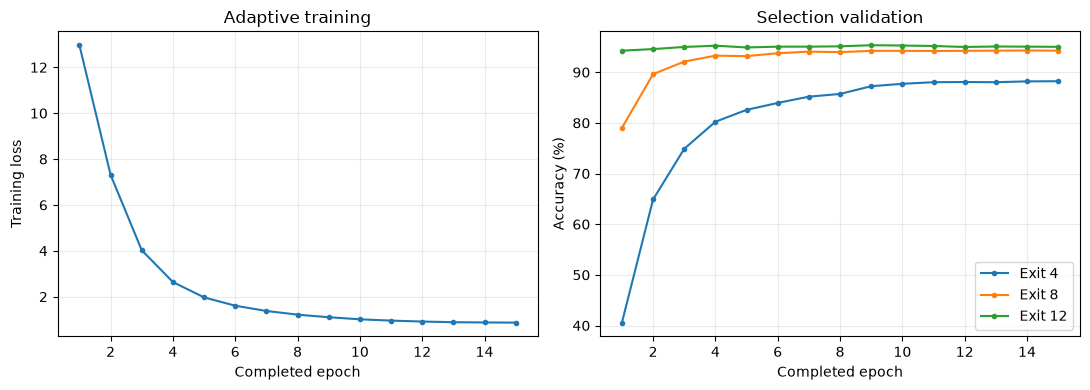

In [10]:
# plotting training loss and selection-validation accuracy by exit
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, marker=".")
axes[0].set(xlabel="Completed epoch", ylabel="Training loss", title="Adaptive training")
for depth in EXITS:
    axes[1].plot(history_df.epoch, history_df[f"accuracy_{depth}"], marker=".", label=f"Exit {depth}")
axes[1].set(xlabel="Completed epoch", ylabel="Accuracy (%)", title="Selection validation")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "adaptive_training.pdf")
plt.show()

## 2D — Confidence calibration and computational cost

### Calibrating the intermediate predictions

Early exits are useful only when their confidence gives meaningful information about correctness. We use **temperature scaling** independently for each exit, fitted by minimising cross-entropy on the calibration portion of `val_policy` [R6]. This calibration does not change predicted classes or the model's learned weights.

The original 3,150-image `val_policy` partition is divided into two nonoverlapping, approximately stratified subsets: **calibration** and **policy selection**. The latter is used to select confidence thresholds and the required compute allowance. The final `test` partition is still untouched.

For a given exit $d$ with logits $z_d$, confidence is the maximum calibrated class probability:

$$q_d(x) = \max_c \operatorname{softmax}\!\left(z_d(x)/T_d\right)_c.$$

Caching logits makes the validation-time threshold search fast. **The cache does not demonstrate real computation savings**: the actual execution path is verified and timed separately later.

In [11]:
# collecting deterministic predictions at all three exits
@torch.inference_mode()
def collect_logits(network, dataset):
    network.eval()
    batches = {depth: [] for depth in EXITS}
    labels_all = []
    for images, labels in tqdm(loader(dataset), desc="collecting logits", leave=False):
        outputs = network.forward_all(images.to(TRAIN_DEVICE))
        for depth in EXITS:
            batches[depth].append(outputs[depth].float().cpu())
        labels_all.append(labels)
    return {d: torch.cat(batches[d]) for d in EXITS}, torch.cat(labels_all)


@torch.inference_mode()
def reference_accuracy(dataset):
    correct = total = 0
    for images, labels in loader(dataset):
        prediction = teacher(images.to(TRAIN_DEVICE)).argmax(-1).cpu()
        correct += int((prediction == labels).sum())
        total += len(labels)
    return 100 * correct / total


if RUN_MODE == "full":
    policy_data = SceneDataset(policy_frame, eval_transform)
    policy_logits, policy_labels = collect_logits(student, policy_data)

    rng = np.random.default_rng(SEED)
    cal_indices, tune_indices = [], []
    for _, group in policy_frame.groupby("label"):
        indices = rng.permutation(group.index.to_numpy())
        cut = len(indices) // 2
        cal_indices.extend(indices[:cut])
        tune_indices.extend(indices[cut:])
    cal_indices = np.array(sorted(cal_indices))
    tune_indices = np.array(sorted(tune_indices))
    assert not np.intersect1d(cal_indices, tune_indices).size
    assert len(cal_indices) + len(tune_indices) == len(policy_data)

    def fit_temperature(logits, labels):
        candidates = np.geomspace(0.5, 10.0, 80)
        losses = [F.cross_entropy(logits / float(t), labels).item() for t in candidates]
        return float(candidates[int(np.argmin(losses))])

    temperatures = {d: fit_temperature(policy_logits[d][cal_indices], policy_labels[cal_indices])
                    for d in EXITS}
    print("Policy calibration / selection images:", len(cal_indices), "/", len(tune_indices))
    display(pd.DataFrame({"Exit": list(EXITS),
                          "Temperature": [f"{temperatures[d]:.3f}" for d in EXITS]}))
else:
    print("Smoke mode: policy calibration and final evaluation are reserved for the full run.")

Policy calibration / selection images: 1565 / 1585


,Exit,Temperature
0,4,1.683
1,8,1.958
2,12,1.748


### Profiling the three fixed depths and three adaptive paths

Every early-exit path starts from the same patch embedding and executes a prefix of the transformer. The cost of a **fixed-depth** mode is measured without evaluating unused earlier heads. A genuinely **adaptive** path must additionally evaluate the earlier heads and confidence calculations before deciding to continue.

We reuse Part 1's `fvcore` counting convention: one multiply-add counts as one operation, with approximate scalar-operation counts for softmax, GELU, elementwise operations, and reductions. Fused attention is disabled only in the **temporary profiling copy**, because otherwise the operator trace may omit its computation. The trained model is never modified for profiling. FLOPs are neither joules nor wall-clock time.

In [12]:
# profiling the computation executed at each depth
class ProfilePath(nn.Module):
    def __init__(self, network, depth, adaptive, temperatures):
        super().__init__()
        self.network = network
        self.depth, self.adaptive, self.temperatures = depth, adaptive, temperatures

    def forward(self, images):
        if self.adaptive:
            return self.network.forward_path(images, self.depth, self.temperatures)
        return self.network.forward_fixed(images, self.depth)


def count_flops(network, sample):
    def elements(value):
        return math.prod(get_shape(value))

    def elementwise(inputs, outputs):
        return elements(outputs[0])

    def gelu(inputs, outputs):
        approximation = inputs[1].toIValue() if len(inputs) > 1 else "none"
        return (9 if approximation == "tanh" else 5) * elements(inputs[0])

    count = FlopCountAnalysis(network, sample).tracer_warnings("none").unsupported_ops_warnings(False)
    for op in ("add", "sub", "mul", "div"):
        count.set_op_handle(f"aten::{op}", elementwise)
    count.set_op_handle("aten::softmax", lambda inputs, outputs: 4 * elements(inputs[0]))
    count.set_op_handle("aten::gelu", gelu)
    for op in ("mean", "sum", "amax"):
        count.set_op_handle(f"aten::{op}", lambda inputs, outputs: elements(inputs[0]))
    result = float(count.total())
    unsupported = dict(count.unsupported_ops())
    if unsupported or result <= 0:
        raise RuntimeError(f"Incomplete FLOPs trace: {unsupported}")
    return result


if RUN_MODE == "full":
    probe = copy.deepcopy(student).cpu().float().eval()
    image_cpu = select_data[0][0].unsqueeze(0)
    with torch.inference_mode():
        ordinary = probe.forward_fixed(image_cpu, 12)
        for block in probe.backbone.blocks:
            block.attn.fused_attn = False
        explicit = probe.forward_fixed(image_cpu, 12)
    torch.testing.assert_close(ordinary, explicit, rtol=1e-3, atol=1e-4)

    cost_fixed, cost_adaptive = {}, {}
    for depth in EXITS:
        cost_fixed[depth] = count_flops(ProfilePath(probe, depth, False, temperatures), image_cpu)
        cost_adaptive[depth] = count_flops(ProfilePath(probe, depth, True, temperatures), image_cpu)
    if not (cost_adaptive[4] < cost_adaptive[8] < cost_adaptive[12]):
        raise RuntimeError("Expected increasing cost with greater depth.")
    if baseline_flops["convention"]["version"] != "fvcore_fma1_scalar_v1":
        raise RuntimeError("Baseline and adaptive FLOPs conventions differ.")
    if abs(cost_fixed[12] / baseline_flops["flops_per_image"] - 1) > 0.01:
        raise RuntimeError("Full-depth cost differs unexpectedly from the static reference.")

    cost_table = pd.DataFrame({
        "Exit": list(EXITS),
        "Fixed GFLOPs": [cost_fixed[d] / 1e9 for d in EXITS],
        "Adaptive-path GFLOPs": [cost_adaptive[d] / 1e9 for d in EXITS],
    })
    display(cost_table.round(4))
    (RUN_DIR / "flops.json").write_text(json.dumps({
        "fixed": cost_fixed, "adaptive": cost_adaptive,
        "baseline": baseline_flops["flops_per_image"],
        "convention": baseline_flops["convention"],
    }, indent=2))
else:
    print("Smoke mode: full FLOPs comparison follows completed training.")

The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
network.backbone.blocks.10, network.backbone.blocks.10.attn, network.backbone.blocks.10.attn.attn_drop, network.backbone.blocks.10.attn.proj, network.backbone.blocks.10.attn.proj_drop, network.backbone.blocks.10.attn.qkv, network.backbone.blocks.10.mlp, network.backbone.blocks.10.mlp.act, network.backbone.blocks.10.mlp.drop1, network.backbone.blocks.10.mlp.drop2, network.backbone.blocks.10.mlp.fc1, network.backbone.blocks.10.mlp.fc2, network.backbone.blocks.10.norm1, network.backbone.blocks.10.norm2, network.backbone.blocks.11, network.backbone.blocks.11.attn, network.backbone.blocks.11.attn.attn_drop, network.backbone.blocks.11.attn.proj, network.backbone.blocks.11.att

,Exit,Fixed GFLOPs,Adaptive-path GFLOPs
0,4,0.4440,0.4440
1,8,0.8591,0.8591
2,12,1.2743,1.2743


### Selecting a stopping policy

At each visited exit, calibrated confidence is compared with a threshold. If confidence exceeds the threshold, inference ends. Otherwise, computation continues **only if the next exit fits the current allowance**. At the maximum permitted depth, the available prediction is returned, including when confidence remains low.

We evaluate a fixed grid of threshold pairs on the **policy-selection** partition. Each pair yields one operating point: classification accuracy versus average executed FLOPs. The primary selected policy is the cheapest that stays within `QUALITY_TOLERANCE_PP` of the frozen teacher's accuracy on the **same policy-selection images**. If no candidate meets that target, we instead report the highest-accuracy candidate and explicitly note the unmet target.

The held-out test set will subsequently evaluate this locked selection and the *predefined* threshold sweep; it will not be used to tune the thresholds.

In [13]:
# choosing exits from cached logits on the policy-selection partition
def choose_depths(logits, temperatures, thresholds, max_depth=12):
    n = len(logits[4])
    result = np.full(n, max_depth, dtype=np.int64)
    if max_depth == 4:
        return result
    conf4 = (logits[4] / temperatures[4]).softmax(-1).amax(-1).numpy()
    result[conf4 >= thresholds[4]] = 4
    if max_depth == 8:
        return result
    conf8 = (logits[8] / temperatures[8]).softmax(-1).amax(-1).numpy()
    result[(result == 12) & (conf8 >= thresholds[8])] = 8
    return result


def policy_metrics(logits, labels, exits, costs):
    labels_np = labels.numpy()
    chosen = np.empty(len(labels_np), dtype=np.int64)
    for depth in EXITS:
        mask = exits == depth
        chosen[mask] = logits[depth].argmax(-1).numpy()[mask]
    return {"accuracy_pct": 100 * np.mean(chosen == labels_np),
            "gflops_per_image": float(np.mean([costs[int(d)] for d in exits]) / 1e9),
            "exit_4_pct": 100 * np.mean(exits == 4),
            "exit_8_pct": 100 * np.mean(exits == 8),
            "exit_12_pct": 100 * np.mean(exits == 12)}


if RUN_MODE == "full":
    tune_logits = {d: policy_logits[d][tune_indices] for d in EXITS}
    tune_labels = policy_labels[tune_indices]
    tune_frame = policy_frame.iloc[tune_indices]
    target_reference = reference_accuracy(SceneDataset(tune_frame, eval_transform))
    target = target_reference - QUALITY_TOLERANCE_PP

    threshold_values = (0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98, 0.99, 0.995, 1.01)
    rows = []
    for t4 in threshold_values:
        for t8 in threshold_values:
            thresholds = {4: t4, 8: t8}
            depths = choose_depths(tune_logits, temperatures, thresholds)
            rows.append({"threshold_4": t4, "threshold_8": t8,
                         **policy_metrics(tune_logits, tune_labels, depths, cost_adaptive)})
    policy_table = pd.DataFrame(rows)
    feasible = policy_table[policy_table.accuracy_pct >= target]
    candidates = feasible if not feasible.empty else policy_table.sort_values(
        ["accuracy_pct", "gflops_per_image"], ascending=[False, True]).head(1)
    selected_policy = candidates.sort_values(["gflops_per_image", "accuracy_pct"],
                                             ascending=[True, False]).iloc[0]
    thresholds = {4: float(selected_policy.threshold_4), 8: float(selected_policy.threshold_8)}
    policy_spec = {"thresholds": thresholds, "temperatures": temperatures,
                   "quality_tolerance_pp": QUALITY_TOLERANCE_PP,
                   "teacher_accuracy_on_policy_selection_pct": target_reference,
                   "target_met": not feasible.empty}
    (RUN_DIR / "policy.json").write_text(json.dumps(policy_spec, indent=2))
    policy_table.to_csv(RUN_DIR / "policy_validation.csv", index=False)
    print(f"Teacher accuracy on policy-selection images: {target_reference:.2f}%")
    print(f"Selected policy: thresholds {thresholds} | target met: {policy_spec['target_met']}")
    display(pd.DataFrame([selected_policy]).round(3))
else:
    print("Smoke mode: confidence-policy selection follows the full run.")

Teacher accuracy on policy-selection images: 95.96%
Selected policy: thresholds {4: 0.9, 8: 0.5} | target met: True


,threshold_4,threshold_8,accuracy_pct,gflops_per_image,exit_4_pct,exit_8_pct,exit_12_pct
40,0.9,0.5,95.016,0.57,70.852,27.95,1.199


## 2E — Held-out evaluation and Pareto frontier

### Final evaluation protocol

**The test images are loaded only in this section, after the adaptive checkpoint and thresholds are fixed.** Static and adaptive models use the same input preprocessing and image order.

The test comparison includes: the frozen static DeiT-Tiny; the adaptive checkpoint forced to exits 4, 8 or 12; and all predetermined confidence-threshold policies. Fixed depth 12 and the static baseline use comparable computation, but their weights can differ because training with early-exit losses also changes the shared transformer.

Cached full-depth outputs are used **only to calculate classification accuracy for many predefined policies efficiently**. Computation for each policy is the average of independently profiled, genuinely executed paths. To verify that this is not hypothetical branching, conditional inference is also executed directly on individual images and timed below.

In [14]:
# evaluating the frozen teacher and all adaptive exits on the held-out test set
if RUN_MODE == "full":
    test_frame = manifest.loc[manifest.split == "test"].reset_index(drop=True)
    test_data = SceneDataset(test_frame, eval_transform)
    test_logits, test_labels = collect_logits(student, test_data)
    teacher_test_accuracy = reference_accuracy(test_data)

    results = [{"configuration": "Static DeiT-Tiny", "type": "static",
                "accuracy_pct": teacher_test_accuracy,
                "gflops_per_image": baseline_flops["flops_per_image"] / 1e9}]
    for depth in EXITS:
        exits = np.full(len(test_labels), depth)
        fixed = policy_metrics(test_logits, test_labels, exits, cost_fixed)
        results.append({"configuration": f"Fixed depth {depth}", "type": "fixed",
                        "accuracy_pct": fixed["accuracy_pct"],
                        "gflops_per_image": cost_fixed[depth] / 1e9})

    policy_results = []
    for row in policy_table.itertuples():
        setting = {4: float(row.threshold_4), 8: float(row.threshold_8)}
        chosen = choose_depths(test_logits, temperatures, setting)
        policy_results.append({"configuration": f"t4={setting[4]:g}, t8={setting[8]:g}",
                               "type": "adaptive", "threshold_4": setting[4],
                               "threshold_8": setting[8],
                               **policy_metrics(test_logits, test_labels, chosen, cost_adaptive)})
    policy_results = pd.DataFrame(policy_results)
    selected_depths = choose_depths(test_logits, temperatures, thresholds)
    selected_test = policy_metrics(test_logits, test_labels, selected_depths, cost_adaptive)
    results.extend(policy_results.to_dict("records"))
    comparison = pd.DataFrame(results)
    comparison.to_csv(RUN_DIR / "pareto_points.csv", index=False)
    display(comparison.loc[comparison.type != "adaptive",
                           ["configuration", "accuracy_pct", "gflops_per_image"]].round(3))
    print("Selected adaptive policy on test:",
          f"{selected_test['accuracy_pct']:.2f}% at {selected_test['gflops_per_image']:.3f} GFLOPs/image")
else:
    print("Smoke mode: the held-out test partition remains unopened.")

,configuration,accuracy_pct,gflops_per_image
0,Static DeiT-Tiny,94.714,1.274
1,Fixed depth 4,86.556,0.444
2,Fixed depth 8,94.063,0.859
3,Fixed depth 12,94.206,1.274


Selected adaptive policy on test: 93.79% at 0.585 GFLOPs/image


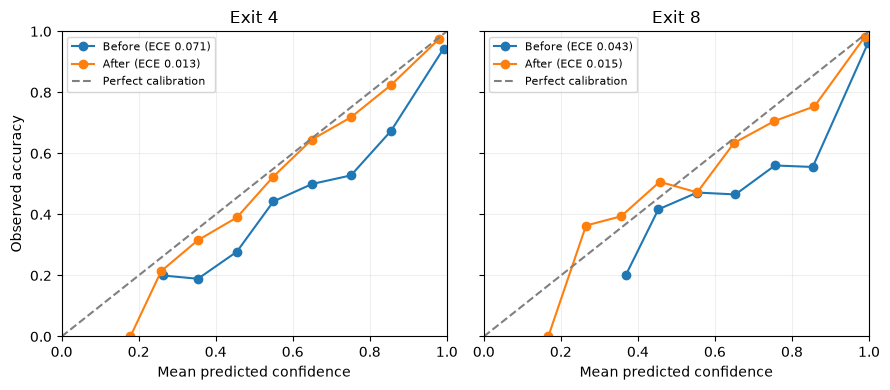

,Exit,Calibration,ECE
0,4,Before,0.0705
1,4,After,0.0133
2,8,Before,0.0431
3,8,After,0.0146


In [23]:
# examining confidence calibration at the early exits
def calibration_bins(logits, labels, temperature, n_bins=10):
    probabilities = (logits / temperature).softmax(-1)
    confidence, predictions = probabilities.max(-1)

    confidence = confidence.numpy()
    correct = (predictions == labels).numpy()

    mean_confidence, observed_accuracy = [], []
    ece = 0.0
    edges = np.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        mask = (
            (confidence >= edges[i])
            & (confidence <= edges[i + 1] if i == n_bins - 1
               else confidence < edges[i + 1])
        )

        if mask.any():
            c = float(confidence[mask].mean())
            a = float(correct[mask].mean())

            mean_confidence.append(c)
            observed_accuracy.append(a)
            ece += mask.mean() * abs(a - c)

    return mean_confidence, observed_accuracy, ece


if RUN_MODE == "full":
    fig, axes = plt.subplots(1, 2, figsize=(9, 4),
                             sharex=True, sharey=True)
    calibration_results = []

    for ax, depth in zip(axes, (4, 8)):
        for name, temperature in (
            ("Before", 1.0),
            ("After", temperatures[depth]),
        ):
            x, y, ece = calibration_bins(
                test_logits[depth], test_labels, temperature
            )

            ax.plot(x, y, "o-", label=f"{name} (ECE {ece:.3f})")

            calibration_results.append({
                "Exit": depth,
                "Calibration": name,
                "ECE": ece,
            })

        ax.plot([0, 1], [0, 1], "--", color="0.5",
                label="Perfect calibration")
        ax.set(
            title=f"Exit {depth}",
            xlabel="Mean predicted confidence",
            xlim=(0, 1),
            ylim=(0, 1),
        )
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Observed accuracy")
    fig.tight_layout()
    fig.savefig(FIGURES / "confidence_calibration.png",
                dpi=300, bbox_inches="tight")
    plt.show()

    display(pd.DataFrame(calibration_results).round(4))

### When does deeper processing correct an early mistake?

Comparing the predictions at different depths reveals whether additional computation helps. An early mistake may be corrected at a deeper exit, but a previously correct prediction may also become incorrect. The two directions must be distinguished rather than assuming that deeper execution always improves individual predictions.

In [24]:
# counting corrections and new errors between successive exits
if RUN_MODE == "full":
    truth = test_labels.numpy()
    predicted = {d: test_logits[d].argmax(-1).numpy() for d in EXITS}
    corrections = []
    for early, deep in ((4, 8), (8, 12)):
        corrections.append({
            "From / to": f"{early} → {deep}",
            "Errors corrected": int(((predicted[early] != truth) & (predicted[deep] == truth)).sum()),
            "Correct predictions lost": int(((predicted[early] == truth) & (predicted[deep] != truth)).sum()),
        })
    display(pd.DataFrame(corrections))

,From / to,Errors corrected,Correct predictions lost
0,4 → 8,574,101
1,8 → 12,118,109


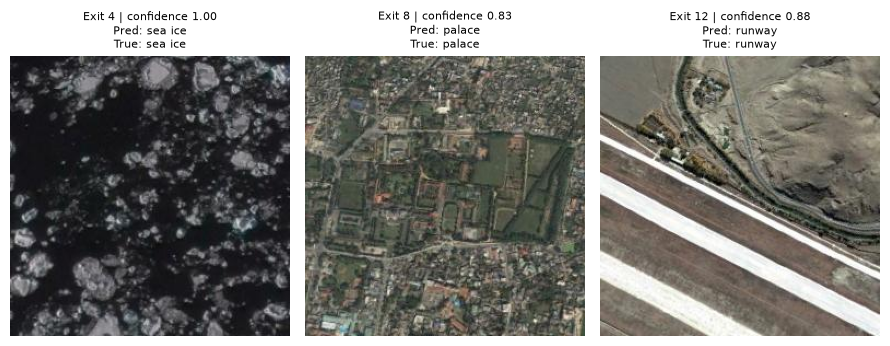

In [28]:
# illustrating images classified at different execution depths
if RUN_MODE == "full":
    sample_rng = np.random.default_rng(SEED + 300)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.6))

    for ax, depth in zip(axes, EXITS):
        candidates = np.flatnonzero(selected_depths == depth)

        if len(candidates) == 0:
            raise RuntimeError(f"No test images reached exit {depth}.")

        i = int(sample_rng.choice(candidates))
        row = test_frame.iloc[i]

        with Image.open(DATA_DIR / row.relative_path) as image:
            ax.imshow(image.convert("RGB"))

        predicted = int(test_logits[depth][i].argmax())
        true_class = int(test_labels[i])
        confidence = float(
            (test_logits[depth][i] / temperatures[depth])
            .softmax(-1).max()
        )

        predicted_name = class_names[predicted].replace("_", " ")
        true_name = class_names[true_class].replace("_", " ")

        ax.set_title(
            f"Exit {depth} | confidence {confidence:.2f}\n"
            f"Pred: {predicted_name}\nTrue: {true_name}",
            fontsize=8
        )
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(FIGURES / "exit_examples.png",
                dpi=300, bbox_inches="tight")
    plt.show()

In [26]:
# comparing confidence decisions with random allocations at matched path counts
if RUN_MODE == "full":
    rng = np.random.default_rng(SEED + 100)
    random_accuracies = []
    for _ in range(30):
        random_depths = rng.permutation(selected_depths)
        random_accuracies.append(policy_metrics(test_logits, test_labels, random_depths,
                                                 cost_adaptive)["accuracy_pct"])
    display(pd.DataFrame({
        "Allocation": ["Confidence-guided", "Random allocation (30 permutations)"],
        "Test accuracy (%)": [f"{selected_test['accuracy_pct']:.2f}",
                              f"{np.mean(random_accuracies):.2f} ± {np.std(random_accuracies, ddof=1):.2f}"],
        "Mean GFLOPs/image": [f"{selected_test['gflops_per_image']:.3f}"] * 2,
    }))

,Allocation,Test accuracy (%),Mean GFLOPs/image
0,Confidence-guided,93.79,0.585
1,Random allocation (30 permutations),89.05 ± 0.19,0.585


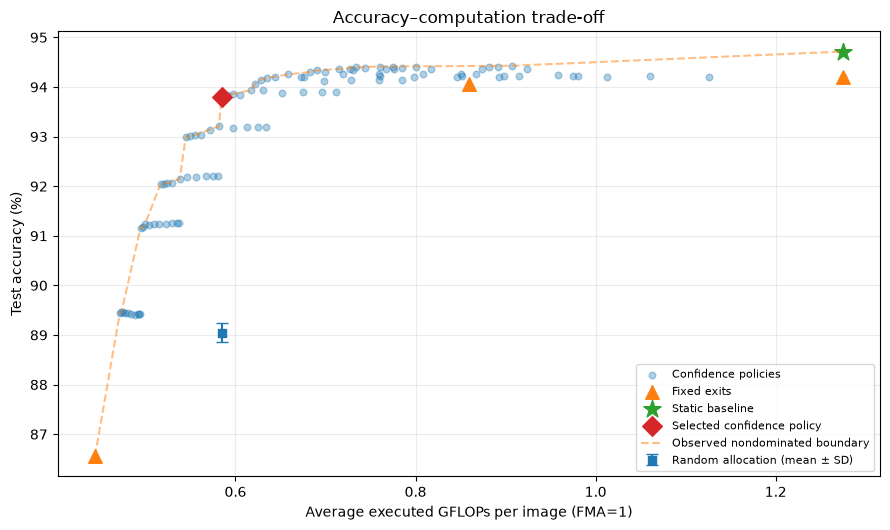

In [25]:
# comparing adaptive policies, fixed exits, and random allocation
if RUN_MODE == "full":
    fig, ax = plt.subplots(figsize=(9, 5.4))

    cloud = comparison.loc[comparison.type == "adaptive"]
    fixed = comparison.loc[comparison.type == "fixed"]
    static = comparison.loc[comparison.type == "static"]

    ax.scatter(
        cloud.gflops_per_image, cloud.accuracy_pct,
        s=23, alpha=0.35, label="Confidence policies"
    )

    ax.scatter(
        fixed.gflops_per_image, fixed.accuracy_pct,
        marker="^", s=95, label="Fixed exits"
    )

    ax.scatter(
        static.gflops_per_image, static.accuracy_pct,
        marker="*", s=170, label="Static baseline"
    )

    ax.scatter(
        selected_test["gflops_per_image"],
        selected_test["accuracy_pct"],
        marker="D", s=100,
        label="Selected confidence policy", zorder=5
    )

    ax.errorbar(
        selected_test["gflops_per_image"],
        np.mean(random_accuracies),
        yerr=np.std(random_accuracies, ddof=1),
        fmt="s", capsize=4,
        label="Random allocation (mean ± SD)", zorder=5
    )

    frontier = comparison.sort_values(
        ["gflops_per_image", "accuracy_pct"],
        ascending=[True, False]
    ).drop_duplicates(
        subset=["gflops_per_image", "accuracy_pct"]
    )

    frontier = frontier.loc[
        frontier.accuracy_pct >
        frontier.accuracy_pct.cummax().shift(fill_value=-1)
    ]

    ax.plot(
        frontier.gflops_per_image,
        frontier.accuracy_pct,
        "--", alpha=0.5,
        label="Observed nondominated boundary"
    )

    ax.set(
        xlabel="Average executed GFLOPs per image (FMA=1)",
        ylabel="Test accuracy (%)",
        title="Accuracy–computation trade-off",
    )

    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()

    fig.savefig(FIGURES / "pareto_with_random.png",
                dpi=300, bbox_inches="tight")
    plt.show()

### Does confidence-based allocation beat input-independent allocation?

A policy can save computation simply by mixing short and long paths. To isolate **which images receive that computation**, we compare our selected confidence policy with input-independent allocations that preserve exactly the same numbers of exits at depths 4, 8 and 12. Random permutations therefore have **the same average path cost** as the selected policy. This control does not require retraining a model.

### Resource-aware inference

The controller also respects an external per-image FLOPs allowance. We replay the held-out images in a **fixed random order**, with four equal phases: full budget, medium budget, tight budget, and full budget again. The three budgets correspond to the measured adaptive path costs at exits 12, 8 and 4.

Under a tight budget, deeper processing is unavailable even when the prediction is uncertain. The figure reports the **executed exit** alongside the imposed depth cap and rolling classification accuracy. This is a controlled resource-response experiment, not evidence of temporal scene change or measured battery energy.

,images,accuracy_pct,mean_gflops,mean_exit
max_depth,,,,
4,1575,86.794,0.444,4.000
8,1575,93.397,0.585,5.361
12,3150,93.746,0.584,5.347


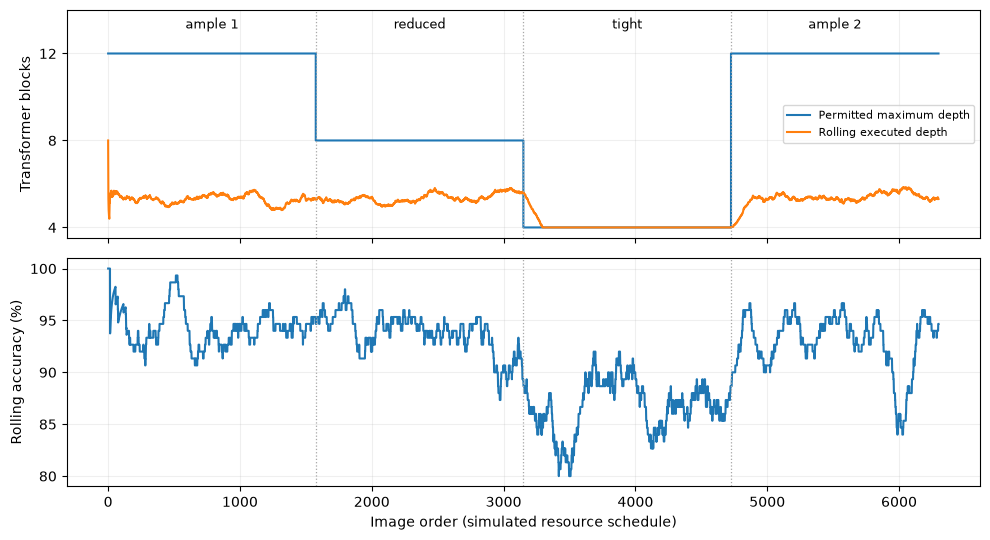

exit,4,8,12
phase,,,
ample 1,69.3,29.0,1.8
reduced,66.0,34.0,0.0
tight,100.0,0.0,0.0
ample 2,66.9,31.3,1.8


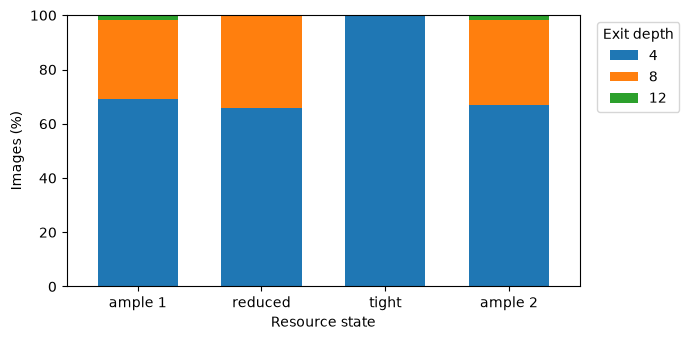

In [27]:
# replaying a changing resource allowance and measuring actual chosen costs
if RUN_MODE == "full":
    rng = np.random.default_rng(SEED + 200)
    order = rng.permutation(len(test_labels))
    segments = np.array_split(order, 4)
    phases = [(12, segments[0]), (8, segments[1]),
              (4, segments[2]), (12, segments[3])]
    parts = []
    for phase_name, (cap, indices) in zip(("ample 1", "reduced", "tight", "ample 2"), phases):
        selected_logits = {d: values[indices] for d, values in test_logits.items()}
        depths = choose_depths(selected_logits, temperatures, thresholds, max_depth=cap)
        metrics = policy_metrics(selected_logits, test_labels[indices], depths, cost_adaptive)
        parts.append(pd.DataFrame({"image": indices, "phase": phase_name, "max_depth": cap, "exit": depths,
                                   "correct": [int(test_logits[d][j].argmax() == test_labels[j])
                                               for j, d in zip(indices, depths)],
                                   "gflops": [cost_adaptive[int(d)] / 1e9 for d in depths],
                                   "budget_gflops": cost_adaptive[cap] / 1e9}))
    trace = pd.concat(parts, ignore_index=True)
    assert (trace["gflops"] <= trace["budget_gflops"] + 1e-9).all()
    trace["rolling_accuracy_pct"] = 100 * trace.correct.rolling(150, min_periods=1).mean()
    trace.to_csv(RUN_DIR / "resource_trace.csv", index=False)
    display(trace.groupby("max_depth").agg(
        images=("image", "size"), accuracy_pct=("correct", lambda x: 100 * x.mean()),
        mean_gflops=("gflops", "mean"), mean_exit=("exit", "mean")).round(3))

    # plotting resource changes with explicit phase boundaries
    phase_names = ["ample 1", "reduced", "tight", "ample 2"]
    lengths = [(trace.phase == phase).sum() for phase in phase_names]
    boundaries = np.r_[0, np.cumsum(lengths)]

    fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

    axes[0].step(
        np.arange(len(trace)), trace.max_depth,
        where="post", label="Permitted maximum depth"
    )
    axes[0].plot(
        trace.exit.rolling(150, min_periods=1).mean(),
        label="Rolling executed depth"
    )
    axes[0].set(
        ylabel="Transformer blocks",
        yticks=[4, 8, 12],
        ylim=(3.5, 14.0),
    )

    for i, phase in enumerate(phase_names):
        midpoint = (boundaries[i] + boundaries[i + 1]) / 2
        axes[0].text(midpoint, 13.15, phase,
                     ha="center", fontsize=9)

    axes[0].legend(loc="center right", fontsize=8)

    axes[1].plot(trace.rolling_accuracy_pct)
    axes[1].set(
        xlabel="Image order (simulated resource schedule)",
        ylabel="Rolling accuracy (%)",
    )

    for ax in axes:
        for boundary in boundaries[1:-1]:
            ax.axvline(boundary, linestyle=":",
                       color="0.65", linewidth=0.9)
        ax.grid(alpha=0.2)

    fig.tight_layout()
    fig.savefig(FIGURES / "resource_response_annotated.png",
                dpi=300, bbox_inches="tight")
    plt.show()

    # displaying the distribution of executed depths in each phase
    proportions = (
        100 * pd.crosstab(
            trace.phase, trace.exit, normalize="index"
        ).reindex(
            index=phase_names, columns=EXITS, fill_value=0
        )
    )

    display(proportions.round(1))

    ax = proportions.plot.bar(
        stacked=True, figsize=(7, 3.5),
        width=0.65, rot=0
    )
    ax.set(
        xlabel="Resource state",
        ylabel="Images (%)",
        ylim=(0, 100),
    )
    ax.legend(title="Exit depth", bbox_to_anchor=(1.02, 1),
              loc="upper left")
    ax.figure.tight_layout()

    ax.figure.savefig(FIGURES / "exit_distribution_compact.png",
                      dpi=300, bbox_inches="tight")
    plt.show()

In [19]:
# evaluating identical test images under each resource allowance
if RUN_MODE == "full":
    budget_results = []

    for max_depth in EXITS:
        depths = choose_depths(
            test_logits,
            temperatures,
            thresholds,
            max_depth=max_depth,
        )

        metrics = policy_metrics(
            test_logits,
            test_labels,
            depths,
            cost_adaptive,
        )

        assert (depths <= max_depth).all()

        budget_results.append({
            "Maximum depth": max_depth,
            "Images": len(test_labels),
            "Accuracy (%)": metrics["accuracy_pct"],
            "GFLOPs / image": metrics["gflops_per_image"],
            "Exit 4 (%)": metrics["exit_4_pct"],
            "Exit 8 (%)": metrics["exit_8_pct"],
            "Exit 12 (%)": metrics["exit_12_pct"],
        })

    budget_table = pd.DataFrame(budget_results)

    display(budget_table.round(2))
    budget_table.to_csv(RUN_DIR / "budget_comparison.csv", index=False)

,Maximum depth,Images,Accuracy (%),GFLOPs / image,Exit 4 (%),Exit 8 (%),Exit 12 (%)
0,4,6300,86.56,0.44,100.00,0.00,0.0
1,8,6300,93.62,0.58,67.75,32.25,0.0
2,12,6300,93.79,0.58,67.75,30.65,1.6


### Verifying real stopping and measuring latency

Policy evaluation above reuses cached logits. To verify genuine computation savings, the same policy is executed **directly**, processing one image at a time. The inference method returns immediately from blocks 4 or 8 when its stopping condition is satisfied; subsequent blocks are not executed.

Batch-one model-forward latency is measured on the same CPU/FP32/one-thread basis as Part 1. Results characterise this computer and runtime, **not an embedded deployment**. The benchmark excludes file reading, image preprocessing, and model loading. Its output is a supporting measurement; the required Pareto plot uses FLOPs.

In [22]:
# validating conditional inference and timing the actual model paths
@torch.inference_mode()
def latency_stats(forward, images, device):
    timings = []
    for image in images:
        sync(device)
        t0 = time.perf_counter_ns()
        forward(image.unsqueeze(0))
        sync(device)
        timings.append((time.perf_counter_ns() - t0) / 1e6)
    return {"median_ms": float(np.median(timings)), "p95_ms": float(np.percentile(timings, 95))}


if RUN_MODE == "full":
    timing_device = choose_device(BENCHMARK_DEVICE)
    threads = torch.get_num_threads()
    if timing_device.type == "cpu":
        torch.set_num_threads(BENCHMARK_THREADS)
    try:
        timed_teacher = copy.deepcopy(teacher).to(timing_device).float().eval()
        timed_student = copy.deepcopy(student).to(timing_device).float().eval()
        sampled_indices = np.random.default_rng(SEED).choice(
            len(test_data), size=min(LATENCY_SAMPLES, len(test_data)), replace=False)
        samples = [test_data[int(i)][0].to(timing_device) for i in sampled_indices]

        # checking real early returns against full inference on the same device
        with torch.inference_mode():
            for i in range(min(8, len(samples))):
                image = samples[i].unsqueeze(0)
                actual, depth, _ = timed_student.infer_one(image, thresholds, temperatures)
                full_logits = timed_student.forward_all(image)
                expected_depth = choose_depths(
                    {d: full_logits[d].cpu() for d in EXITS}, temperatures, thresholds)[0]
                torch.testing.assert_close(actual, full_logits[depth], rtol=1e-4, atol=1e-5)
                assert depth == expected_depth
        del actual

        paths = {
            "Static baseline": lambda x: timed_teacher(x),
            "Fixed 4": lambda x: timed_student.forward_fixed(x, 4),
            "Fixed 8": lambda x: timed_student.forward_fixed(x, 8),
            "Fixed 12": lambda x: timed_student.forward_fixed(x, 12),
            "Confidence policy": lambda x: timed_student.infer_one(x, thresholds, temperatures),
        }
        # warming each measured path before the timed sequence
        with torch.inference_mode():
            for fn in paths.values():
                for image in samples[:5]:
                    fn(image.unsqueeze(0))
        latency_rows = [{"Execution": name, **latency_stats(fn, samples, timing_device)}
                        for name, fn in paths.items()]
        latency_table = pd.DataFrame(latency_rows)
        latency_table.to_csv(RUN_DIR / "latency.csv", index=False)
        display(latency_table.round(2))
    finally:
        torch.set_num_threads(threads)

,Execution,median_ms,p95_ms
0,Static baseline,5.91,6.11
1,Fixed 4,2.04,2.26
2,Fixed 8,3.87,3.93
3,Fixed 12,5.74,5.80
4,Confidence policy,2.05,3.98


## 2F — Results and interpretation

________________________________________________________________________________________________________
### Relation to prior work:

The adaptive architecture builds upon established research on efficient vision transformers and early-exit inference. LGViT [R3] identifies limitations in shallow representations and motivates the use of intermediate supervision and knowledge distillation. E3C [R2] demonstrates the relevance of early-exit inference to remote sensing while highlighting the computational overhead introduced by additional classification heads and gating mechanisms. Accordingly, the proposed architecture uses two lightweight intermediate heads and a confidence-based stopping rule, with their execution costs explicitly included in the evaluation.

Recent work such as EnViT [R8] further identifies interference between early and late exits as a potential source of accuracy degradation. We therefore preserve the original static baseline and evaluate the full-depth output of the adaptively trained model separately. Confidence calibration and policy selection are performed using held-out validation data, following established calibration principles [R6].

These choices provide a focused implementation of adaptive depth without introducing additional architectural mechanisms. Their effectiveness is assessed through exit-specific accuracy, conditional execution, latency measurements, and the resulting accuracy–FLOPs frontier.

___________________________________________________________________________

In the evaluation code below, the central evaluation is the **accuracy–FLOPs frontier**, interpreted together with the original static reference, fixed-depth execution of the adaptive checkpoint, and the input-independent allocation control. A useful adaptive policy should preserve meaningful scene-recognition accuracy while avoiding computation that provides little benefit. Its advantages must be established from the measurements rather than assumed from the architecture.

Three limitations remain important: (1) confidence may be high on incorrect predictions; (2) additional blocks do not necessarily correct errors; and (3) lower FLOPs do not guarantee proportional latency or energy savings. The published RESISC45 split is a benchmark, not an evaluation of geographic or temporal distribution shift.

Without an additional no-distillation training run, the isolated contribution of knowledge distillation cannot be quantified; our comparison evaluates the complete distilled early-exit system. The final summary below is generated from completed experiments. Results from `smoke` mode are excluded.

In [21]:
# summarising the selected adaptive policy and comparison with the static reference
if RUN_MODE == "full":
    summary = {
        "static_test_accuracy_pct": teacher_test_accuracy,
        "static_gflops_per_image": baseline_flops["flops_per_image"] / 1e9,
        "adaptive_test_accuracy_pct": selected_test["accuracy_pct"],
        "adaptive_gflops_per_image": selected_test["gflops_per_image"],
        "accuracy_change_pp": selected_test["accuracy_pct"] - teacher_test_accuracy,
        "flops_reduction_pct": 100 * (1 - selected_test["gflops_per_image"] /
                                     (baseline_flops["flops_per_image"] / 1e9)),
        "exit_fraction_pct": {str(d): selected_test[f"exit_{d}_pct"] for d in EXITS},
        "thresholds": thresholds,
        "temperatures": temperatures,
        "resource_cap_violations": int((trace["gflops"] > trace["budget_gflops"] + 1e-9).sum()),
        "baseline_checkpoint_sha256": sha256(BASELINE_PATH),
        "adaptive_checkpoint_sha256": sha256(BEST_PATH),
        "dataset": "NWPU-RESISC45",
        "test_images": len(test_data),
    }
    (RUN_DIR / "test_summary.json").write_text(json.dumps(summary, indent=2))
    display(pd.Series({
        "Static test accuracy (%)": f"{summary['static_test_accuracy_pct']:.2f}",
        "Adaptive test accuracy (%)": f"{summary['adaptive_test_accuracy_pct']:.2f}",
        "Accuracy difference (pp)": f"{summary['accuracy_change_pp']:+.2f}",
        "Static GFLOPs / image": f"{summary['static_gflops_per_image']:.3f}",
        "Adaptive GFLOPs / image": f"{summary['adaptive_gflops_per_image']:.3f}",
        "FLOPs saved (%)": f"{summary['flops_reduction_pct']:.2f}",
    }, name="Final comparison").to_frame())
else:
    print("Smoke run complete. The test set has not been evaluated.")

,Final comparison
Static test accuracy (%),94.71
Adaptive test accuracy (%),93.79
Accuracy difference (pp),-0.92
Static GFLOPs / image,1.274
Adaptive GFLOPs / image,0.585
FLOPs saved (%),54.13


### Conclusion 

The jointly trained adaptive DeiT-Tiny achieved **93.79% classification accuracy** on the held-out RESISC45 test partition, compared with **94.71%** for the original static baseline. Its average computational cost decreased from **1.274 to 0.585 GFLOPs per image**, representing a **54.13% reduction in computation for a 0.92-percentage-point loss in accuracy**.

The results demonstrate the value of input-dependent computation rather than simply reducing network depth. At matched computational cost, confidence-guided execution achieved 93.79% accuracy, compared with 89.05% for input-independent random allocation. Approximately 67.75% of images were classified after four transformer blocks, 30.65% after eight, and only 1.60% required the final exit. These findings indicate that calibrated confidence provides a useful signal for allocating additional processing to selected inputs.

The resource-aware experiments further demonstrate that execution can be constrained by an external compute allowance. Restricting the maximum depth to eight blocks preserved 93.62% test accuracy, whereas a four-block limit reduced accuracy to 86.56%. The adaptive system respected all evaluated constraints, while CPU measurements showed corresponding improvements in median inference latency. On the evaluated CPU, confidence-guided inference reduced median latency by 65.3% and p95 latency by 34.9% relative to the static baseline. These measurements complement the 54.13% reduction in average FLOPs, demonstrating that adaptive execution also provides practical runtime benefits under the tested conditions.

The findings support the effectiveness of shared-weight, early-exit inference for reducing average needed computation in remote sensing scene classification tasks during its deployment. They also establish its limitations: joint training slightly reduced full-depth accuracy, confidence-based stopping introduced additional errors, and computational savings do not directly establish equivalent energy savings. The experiments therefore demonstrate a measurable accuracy–efficiency trade-off rather than generally superior perfomance on inference.

### Output files

```text
runs/adaptive_deit_tiny_seed42/
├── config.json                   # training settings and baseline identity
├── environment.json              # Python, dependencies and hardware environment
├── best.pt                       # selected shared early-exit model
├── last.pt                       # resumable training state
├── history.csv                   # loss and accuracy at all three exits
├── flops.json                    # fixed and adaptive path costs
├── policy.json                   # calibrated temperatures and selected thresholds
├── policy_validation.csv         # threshold sweep on held-out policy validation
├── pareto_points.csv             # final measured test operating points
├── resource_trace.csv            # simulated resource-response evaluation
├── latency.csv                   # measured conditional batch-one latency
├── test_summary.json             # final accuracy and computation comparison
└── figures/
    ├── adaptive_training.pdf
    ├── pareto_frontier.pdf
    └── resource_response.pdf
```

The datasets and checkpoints remain outside Git. The two notebooks and their dependency definitions are sufficient to reconstruct the training and evaluation procedure from the independently obtained RESISC45 dataset. This study evaluates adaptation *within* DeiT-Tiny rather than claiming superiority over every convolutional or transformer architecture.

## Sources

**[C1]** *Project — Adaptive Inference for Edge AI*, Big Data at the Edge, 2026.

**[R1]** G. Cheng, J. Han, and X. Lu (2017). *Remote Sensing Image Scene Classification: Benchmark and State of the Art*. *Proceedings of the IEEE*, 105(10), 1865–1883. [DOI](https://doi.org/10.1109/JPROC.2017.2675998).

**[R2]** Y. Zhao, S. Li, and X. Feng (2025). *Lightweight Remote Sensing Scene Classification on Edge Devices via Knowledge Distillation and Early-exit*. ACM Multimedia. [Paper](https://arxiv.org/abs/2507.20623). Closely related adaptive remote sensing system based on GFNet.

**[R3]** G. Xu et al. (2023). *LGViT: Dynamic Early Exiting for Accelerating Vision Transformer*. [Paper](https://arxiv.org/abs/2308.00255). Intermediate exits and shallow representation learning.

**[R4]** H. Touvron et al. (2021). *Training data-efficient image transformers & distillation through attention*. ICML. [Paper](https://proceedings.mlr.press/v139/touvron21a.html). [Pretrained checkpoint](https://huggingface.co/timm/deit_tiny_patch16_224.fb_in1k).

**[R5]** G. Hinton, O. Vinyals, and J. Dean (2015). *Distilling the Knowledge in a Neural Network*. [Preprint](https://arxiv.org/abs/1503.02531).

**[R6]** C. Guo, G. Pleiss, Y. Sun, and K. Q. Weinberger (2017). *On Calibration of Modern Neural Networks*. ICML. [Paper](https://proceedings.mlr.press/v70/guo17a.html).

**[R7]** [fvcore FLOP-counting conventions](https://detectron2.readthedocs.io/en/stable/modules/fvcore.html). Counting conventions are identical to Part 1.


**[R8]** Dong, Y., He, Q., Rui, P., Zheng, Z., Li, Z., Chen, F., Jin, H., & Yang, Y. (2026). *EnViT: Enhancing the Performance of Early-Exit Vision Transformers via Exit-Aware Structured Dropout-Enabled Self-Distillation.* Proceedings of the AAAI Conference on Artificial Intelligence, 40(25), 20852–20860. https://doi.org/10.1609/aaai.v40i25.39225


The notebooks are licensed under Apache-2.0. RESISC45 imagery and external pretrained weights retain their respective upstream licenses. No dataset images or model checkpoints are redistributed in the repository.